# Constants

In [1]:
from pathlib import Path
import pandas as pd
import sqlite3
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import shutil

import warnings

warnings.simplefilter("ignore", pd.errors.PerformanceWarning)

Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

Markers = {1: 'o',
 2: '^',
 3: 's',
 4: '*',
 5: '>',
 6: 'v',
 7: 'X',
 8: '<',
 9: 'p',
 10: '8',
 11: 'd',
 12:'P',
 13:'D',
 14:'o',
 15:'^'}

Lines = {1: '-',
 2: '--',
 3: '-,',
 4: ':',
 5: '-',
 6: '--',
 7: '-,',
 8: ':',
 9: '-',
 10: '--',
 11: '-,',
 12: ':',
 13: '-',
 14: '--',
 15: '-,',
 16: ':'}

# Settings

In [2]:
# ======================
# CONFIG
# ======================

CROP = 'Lentil'

BRANCHES = {
    "master": "Lentil",
}

REPO_PATH = Path(r"C:\GitHubRepos\ApsimX")

SIM_FILES = [
    Path(REPO_PATH) / 'Prototypes/Lentil/Lentil.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2019_NSW_Greenethorpe_Mixed_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Kalkee_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Riverton_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_Methul_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_NSW_RankinsSprings_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2022_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Pinery_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Dooen_Lentil_Detailed.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Vic_Ouyen_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2023_Qld_Gatton_Mixed_Light.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_NSW_Greenethorpe_Mixed_NFix.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_SA_Warnertown_Lentil_Satellite.apsimx',
    Path(REPO_PATH) / 'Prototypes/Lentil/NaPA/2024_Vic_Walpeup_Lentil_Satellite.apsimx'
]

APSIM_EXE = r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe"

APSIM_SOLUTION = r"C:\GitHubRepos\ApsimX\ApsimX.sln"

REPORT_LIBRARY = r"C:/GitHubRepos/ApsimX/Prototypes/Lentil/Report_lib.apsimx"

# Helpers for setting up and running .apsim files

In [3]:
def validate_run_branches():
    invalid = [b for b in RUN_BRANCHES if b not in BRANCHES]
    if invalid:
        raise ValueError(f"Invalid RUN_BRANCHES: {invalid}")

# ======================
# APSIM / DB UTILITIES
# ======================

def checkout_branch(branch):
    subprocess.run(["git", "checkout", branch],
                   cwd=REPO_PATH,
                   check=True)

def build_apsim():
    subprocess.run(
        ["dotnet", "build", APSIM_SOLUTION, "-c", "Release"],
        cwd=REPO_PATH,
        check=True
    )
    return 
    
def run_apsim(sim_file):
    """
    High-level runner:
    - writes apply file
    - runs APSIM
    """

    apply_file = write_apply_file(sim_file)
    return run_apsim_with_apply(sim_file, apply_file)

def run_apsim_with_apply(sim_file, apply_file):
    """
    Executes APSIM using a pre-generated apply file.
    """

    print(f"▶ Running APSIM: {sim_file.name}")

    result = subprocess.run(
        [
            APSIM_EXE,
            sim_file,
            "--apply",
            apply_file
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    print(result.stdout)

    return result
    
def db_path(sim_file):
    return sim_file.with_suffix(".db")

def branch_db_path(sim_file, branch):
    return sim_file.parent / f"{sim_file.stem}_{branch}.db"

def reset_repo():
    print("🔄 Resetting tracked files only")

    subprocess.run(
        ["git", "reset", "--hard"],
        cwd=REPO_PATH,
        check=True
    )

def read_table(db_file, table):
    # if not db_file.exists():
    #     return None
    with sqlite3.connect(db_file) as conn:
        df = pd.read_sql(f"SELECT * FROM [{table}]", conn)

  
    df.columns = [
        c.strip().replace('"', '').replace("'", '')
        for c in df.columns
    ]

    return df

def should_run(branch_name):
    return branch_name in RUN_BRANCHES

def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """

    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    lines.append(f"add [AnalysisReport] from {REPORT_LIBRARY} to all [Zone]")
    
    # ---------------------------------------------
    # Inject Spectral model into each simulation
    # ---------------------------------------------
    #lines.append("add [Spectral] to all [Zone]")

    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run {sim_file}")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

# load_branch_data

In [4]:
def load_branch_data(branch_name, git_branch):
    if should_run(branch_name):
        reset_repo()
        checkout_branch(git_branch)
        build_apsim()

    frames = []

    for sim in SIM_FILES:
        db = branch_db_path(sim, branch_name)

        # --- Run APSIM ---
        if should_run(branch_name):
            print("")
            print(f"▶ Running APSIM [{branch_name}]: {sim.name}")
            run_apsim(sim)

            original_db = sim.with_suffix(".db")
            branch_db = branch_db_path(sim, branch_name)

            shutil.copyfile(original_db, branch_db)

        else:
            print(f"⏭ Skipping run [{branch_name}]: {sim.name}")

        if not db.exists():
            print(f"❌ DB not created: {db}")
            continue

        # ======================================================
        # ✅ READ DATABASE
        # ======================================================
        with sqlite3.connect(db) as conn:

            tables = pd.read_sql(
                "SELECT name FROM sqlite_master WHERE type='table';",
                conn
            )["name"].tolist()

            print(f"{sim.name} tables: {tables}")

            # ---------------------------------------------
            # ✅ Observed
            # ---------------------------------------------
            obs = None
            if "Observed" in tables:
                obs = pd.read_sql("SELECT * FROM [Observed]", conn)
                obs["type"] = "obs"

            # ---------------------------------------------
            # ✅ Predictions
            # ---------------------------------------------
            pred = None
            if "AnalysisReport" in tables:
                pred = pd.read_sql("SELECT * FROM [AnalysisReport]", conn)
                pred["type"] = "pred"

            if pred is None and obs is None:
                continue

            # ---------------------------------------------
            # ✅ CHECK SimulationID alignment (per file)
            # ---------------------------------------------
            if pred is not None and obs is not None:

                pred_ids = set(pred["SimulationID"].drop_duplicates())
                obs_ids  = set(obs["SimulationID"].drop_duplicates())

                # simulations in pred but not in obs
                missing_ids = pred_ids - obs_ids

                if missing_ids:
                    print(f"\n⚠️ Missing observed simulations in {sim.name}:")
                    print(f"Count: {len(missing_ids)}")

                    # attempt to print identifying info from pred
                    cols_to_show = [
                        c for c in [
                            "SimulationID",
                            "Simulation.Name",   # if present
                            "Experiment",
                            "TOS",
                            "Variety",
                            "WaterTrt"
                        ] if c in pred.columns
                    ]

                    missing_rows = (
                        pred[pred["SimulationID"].isin(missing_ids)]
                        [cols_to_show]
                        .drop_duplicates()
                        .sort_values("SimulationID")
                    )

                    print(missing_rows.head(20))  # limit output            

            # ---------------------------------------------
            # ✅ Attach metadata (branch, file)
            # ---------------------------------------------
            if pred is not None:
                pred["branch"] = branch_name
                pred["file"] = sim.name

            if obs is not None:
                obs["branch"] = branch_name
                obs["file"] = sim.name

            # ---------------------------------------------
            # ✅ Combine
            # ---------------------------------------------
            df = pd.concat(
                [x for x in [pred, obs] if x is not None],
                ignore_index=True
            )

            frames.append(df)

    if not frames:
        raise RuntimeError(f"No data loaded for branch {branch_name}")

    return pd.concat(frames, ignore_index=True)

def load_all():
    return pd.concat([
        load_branch_data(name, git_branch)
        for name, git_branch in BRANCHES.items()
    ], ignore_index=True)

# Run selected branches and simulations

In [5]:
# ======================
# RUN CONTROL
# ======================

# Options:
#RUN_BRANCHES = []                    # run nothing (use existing DBs)
#RUN_BRANCHES = list(BRANCHES.keys())   # run all branches
RUN_BRANCHES = ["master"]
# RUN_BRANCHES = ["working"]

validate_run_branches()

# ======================
# EXECUTE PIPELINE
# ======================

raw = load_all()

🔄 Resetting tracked files only

▶ Running APSIM [master]: Lentil.apsimx
▶ Running APSIM: Lentil.apsimx

Lentil.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', 'SowingReport', '_Messages', 'HarvestReport', 'SupReport', '_Simulations', '_Checkpoints', '_Units', 'HarvestObsPred', 'DailyObsPred', 'AnalysisReport', 'spec', 'specdaily', 'Report', 'Observed', 'Roberts_etal_1988', 'Summerfield_etal_1985', 'Roberts_etal_1986']

⚠️ Missing observed simulations in Lentil.apsimx:
Count: 48
       SimulationID                    Simulation.Name   Experiment   TOS
57775           779   Roberts1986Pp8to16hDurat0CvLaird  Roberts1986  None
57975           780   Roberts1986Pp16to8hDurat0CvLaird  Roberts1986  None
59290           781   Roberts1986Pp8to16hDurat9CvLaird  Roberts1986  None
59590           782   Roberts1986Pp16to8hDurat9CvLaird  Roberts1986  None
59835           783  Roberts1986Pp8to16hDurat13CvLaird  Roberts1986  None
59935           784  Roberts1986Pp16to8hDurat13CvLaird  

# Enforce indicies on observed data

In [6]:
def enforce_indices_to_observed(df, indices_to_fill):
    """
    Make table of index values from predicted data and copy them to the observed data so they have complete indices.
    """

    keys = ["branch", "file", "SimulationID"]

    pred = df[df["type"] == "pred"].copy()
    pred.set_index(keys,inplace=True)
    red = pred.sort_index().copy()
    obs  = df[df["type"] == "obs"].copy()
    obs.set_index(keys, inplace=True)
    obs = obs.sort_index().copy()

    # -------------------------------
    # BUILD METADATA
    # -------------------------------
    meta = pred.loc[:,indices_to_fill].drop_duplicates()
    meta = meta.sort_index().copy()

    # -------------------------------
    # MERGE INTO OBS
    # -------------------------------
    for i in meta.index:
        try:
            obs.loc[i,indices_to_fill] = meta.loc[i,indices_to_fill].values
        except:
            #print(i)#
            do="nothing"
   
    # -------------------------------
    # RECOMBINE
    # -------------------------------
    obs = obs.reset_index()
    pred = pred.reset_index()
    result = pd.concat([pred, obs], ignore_index=True)

    return result

# to_tidy

In [7]:
def to_tidy(df):

    df = df.copy()

    # rename Simulation.Name
    if "Simulation.Name" in df.columns:
        df = df.rename(columns={"Simulation.Name": "SimulationName"})
        
    # ---------------------------------------------
    # ✅ Define columns that must NEVER be melted
    # ---------------------------------------------
    protected_cols = [
        "SimulationID",
        "CheckpointID",
        "Clock.Today",
        "SimulationName",
        "Experiment",
        "Zone",
        "file",
        "branch",
        "type"
    ]

    # include any that actually exist
    protected_cols = [c for c in protected_cols if c in df.columns]

    # ---------------------------------------------
    # ✅ Identify numeric columns
    # ---------------------------------------------
    
    possible_numeric = df.columns.difference(protected_cols)

    for col in possible_numeric:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # ---------------------------------------------
    # ✅ Value columns = numeric BUT NOT protected
    # ---------------------------------------------
    value_cols = [
        c for c in numeric_cols
        if c not in protected_cols
    ]

    # ---------------------------------------------
    # ✅ ID columns = everything else
    # ---------------------------------------------
    id_cols = [c for c in df.columns if c not in value_cols]
    
    # ---------------------------------------------
    # ✅ Enforce indices BEFORE melt
    # ---------------------------------------------
    indices_to_fill = ['Experiment','SimulationName',f'{CROP}.SowingData.Cultivar']
    df = enforce_indices_to_observed(df, indices_to_fill)
    
    # ---------------------------------------------
    # ✅ Melt
    # ---------------------------------------------
    tidy = df.melt(
        id_vars=id_cols,
        value_vars=value_cols,
        var_name="variable",
        value_name="value"
    )

    return tidy.dropna(subset=["value"])

# Tidy raw data

In [8]:
# ✅ Ensure SimulationName exists (from AnalysisReport)
if "Simulation.Name" in raw.columns:
    raw = raw.rename(columns={"Simulation.Name": "SimulationName"})

# ✅ Convert to tidy format
tidy = to_tidy(raw)

# Functions to get data for graphing

In [9]:
def get_harvest_aligned(tidy, variable, filters=None):
    """
    Align data at harvest stage (HarvestRipe).

    Behaviour:
    - Applies optional filters
    - Filters to HarvestRipe stage (implicit)
    - If observed data exists:
        → returns aligned obs vs pred
    - If NOT:
        → returns predictions only (obs = NaN)

    Always returns one row per simulation.
    """

    # -------------------------------
    # APPLY FILTERS
    # -------------------------------
    df = apply_filters(tidy, filters)

    # -------------------------------
    # HARVEST FILTER (implicit)
    # -------------------------------
    if f"{CROP}.Phenology.CurrentStageName" not in df.columns:
        raise KeyError(f"Missing {CROP}.Phenology.CurrentStageName in tidy data")

    df = df[df[f"{CROP}.Phenology.CurrentStageName"] == "HarvestRipe"]

    # -------------------------------
    # Slice out variable to graph
    # -------------------------------
    df = df[df.variable == variable].copy()

    # -------------------------------
    # SPLIT OBS / PRED
    # -------------------------------
    obs = df[df["type"] == "obs"].copy()
    pred = df[df["type"] == "pred"].copy()

    # -------------------------------
    # COLLAPSE TO ONE ROW PER SIMULATION
    # -------------------------------
    keys = ["branch", "file", "SimulationID"]

    pred = pred.sort_values("Clock.Today").groupby(keys).tail(1)

    if obs.empty:
        # ✅ No observed data → prediction only mode
        print("\nNo observed data — returning predictions only")

        pred = pred.copy()
        pred["pred"] = pred["value"]
        pred["obs"] = np.nan

        return pred

    # collapse obs as well
    obs = obs.sort_values("Clock.Today").groupby(keys).tail(1)

    # -------------------------------
    # SAFE MERGE (1:1)
    # -------------------------------
    aligned = pred.merge(
        obs,
        on=keys,
        how="inner",
        suffixes=("_pred", "_obs")
    )

    # -------------------------------
    # BUILD OUTPUT
    # -------------------------------
    aligned["pred"] = aligned["value_pred"]
    aligned["obs"] = aligned["value_obs"]

    return aligned

In [10]:
def get_daily_aligned(tidy, variable, filters=None):
    """
    Align data at daily resolution.

    - applies filters
    - aligns obs/pred on SimulationID + date
    """

    df = apply_filters(tidy, filters)

    df = df[df["variable"] == variable].copy()

    obs = df[df["type"] == "obs"]
    pred = df[df["type"] == "pred"]

    aligned = pred.merge(
        obs,
        on=["file", "SimulationID", "Clock.Today"],
        how="inner",
        suffixes=("_pred", "_obs")
    )

    aligned["branch"] = aligned["branch_pred"]
    aligned["pred"] = aligned["value_pred"]
    aligned["obs"] = aligned["value_obs"]

    return aligned

In [11]:
def apply_filters(tidy, filters):
    """
    Apply generic filters to tidy dataframe.

    filters = {
        "column_or_variable": [allowed_values],
    }

    Works for:
    - metadata columns (e.g. Experiment, branch)
    - APSIM variables (via variable/value pairs)
    """

    if filters is None:
        return tidy.copy()

    df = tidy.copy()

    for key, values in filters.items():

        if key in df.columns:
            # ✅ direct column filter
            df = df[df[key].isin(values)]

        else:
            # ✅ variable-based filter
            mask = (
                (df["variable"] == key)
                & (df["value"].isin(values))
            )

            valid_rows = df.loc[
                mask,
                ["branch", "file", "SimulationID", "Clock.Today"]
            ]

            df = df.merge(
                valid_rows,
                on=["branch", "file", "SimulationID", "Clock.Today"],
                how="inner"
            )

    return df

# Function plot observed vs predicted by branch

In [12]:
def plot_obs_pred_by_branch(
    tidy,
    variable,
    mode="harvest",
    filters=None,
    color_by=None,
    marker_by=None,
    size_by=None,
    fill_by=None
):
    
    # -------------------------------
    # ALIGN DATA
    # -------------------------------
    if mode == "harvest":
        pivot = get_harvest_aligned(tidy, variable, filters)

    elif mode == "daily":
        pivot = get_daily_aligned(tidy, variable, filters)

    else:
        raise ValueError("mode must be 'harvest' or 'daily'")

    # -------------------------------
    # ATTACH METADATA
    # -------------------------------
    meta = tidy[[
        "branch", "file", "SimulationID", "Experiment", f"{CROP}.SowingData.Cultivar"
    ]].drop_duplicates()

    pivot = pivot.merge(
        meta,
        on=["branch", "file", "SimulationID"],
        how="left"
    )

    # -------------------------------
    # BUILD GROUPINGS
    # -------------------------------
    branches = sorted(pivot["branch"].unique())

    # Color
    color_map = {}
    if color_by:
        vals = sorted(pivot[color_by].dropna().unique())
        colors = list(Colors.values())
        color_map = {v: colors[i % len(colors)] for i, v in enumerate(vals)}

    # Marker
    marker_map = {}
    if marker_by:
        vals = sorted(pivot[marker_by].dropna().unique())
        markers = list(Markers.values())
        marker_map = {v: markers[i % len(markers)] for i, v in enumerate(vals)}

    # Size
    size_map = {}
    if size_by:
        vals = sorted(pivot[size_by].dropna().unique())
        sizes = np.linspace(30, 120, len(vals))
        size_map = {v: sizes[i] for i, v in enumerate(vals)}

    # Fill (True=filled, False=hollow)
    fill_map = {}
    if fill_by:
        vals = sorted(pivot[fill_by].dropna().unique())
        fill_map = {v: (i == 0) for i, v in enumerate(vals)}

    # -------------------------------
    # PLOT
    # -------------------------------
    fig, axes = plt.subplots(
        1, len(branches),
        figsize=(6 * len(branches), 6),
        sharex=True, sharey=True
    )

    if len(branches) == 1:
        axes = [axes]

    max_val = max(pivot["obs"].max(), pivot["pred"].max())
    lims = [0, max_val]

    group_cols = [c for c in [color_by, marker_by, size_by, fill_by] if c]

    for ax, branch in zip(axes, branches):

        g = pivot[pivot["branch"] == branch]

        grouped = g.groupby(group_cols) if group_cols else [(None, g)]

        for key, sub in grouped:

            color_val = sub[color_by].iloc[0] if color_by else None
            marker_val = sub[marker_by].iloc[0] if marker_by else None
            size_val = sub[size_by].iloc[0] if size_by else None
            fill_val = sub[fill_by].iloc[0] if fill_by else None

            facecolor = color_map.get(color_val, "grey")
            edgecolor = color_map.get(color_val, "grey")

            if fill_by and not fill_map.get(fill_val, True):
                facecolor = "none"

            ax.scatter(
                sub["obs"],
                sub["pred"],
                facecolors=facecolor,
                edgecolors=edgecolor,
                marker=marker_map.get(marker_val, "o"),
                s=size_map.get(size_val, 50),
                alpha=0.7
            )

        ax.plot(lims, lims, "k--", linewidth=1)

        ax.set_title(branch)
        ax.set_xlabel(f"Observed {variable}")
        ax.set_ylabel(f"Predicted {variable}")

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(alpha=0.2)

    # LEGENDS (dynamic stacking)
    # -------------------------------
    legend_y = 1.20   # starting position
    legend_spacing = 0.06  # base vertical gap

    def estimate_rows(n_items, max_cols):
        return int(np.ceil(n_items / max_cols))

    # ---------------------------
    # Color legend
    # ---------------------------
    if color_by and color_map:
        max_cols = min(len(color_map), 6)
        rows = estimate_rows(len(color_map), max_cols)

        handles = [
            plt.Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=color_map[val],
                label=str(val),
                markersize=8
            )
            for val in color_map
        ]

        fig.legend(
            handles=handles,
            title=color_by,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=max_cols,
            frameon=False
        )

        legend_y -= (rows + 1) * legend_spacing

    # ---------------------------
    # Marker legend
    # ---------------------------
    if marker_by and marker_map:
        max_cols = min(len(marker_map), 6)
        rows = estimate_rows(len(marker_map), max_cols)

        handles = [
            plt.Line2D(
                [0], [0],
                marker=marker_map[val],
                color='k',
                linestyle='None',
                label=str(val),
                markersize=8
            )
            for val in marker_map
        ]

        fig.legend(
            handles=handles,
            title=marker_by,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=max_cols,
            frameon=False
        )

        legend_y -= (rows + 1) * legend_spacing

    # ---------------------------
    # Fill legend
    # ---------------------------
    if fill_by and fill_map:
        max_cols = min(len(fill_map), 6)
        rows = estimate_rows(len(fill_map), max_cols)

        handles = []
        for val, filled in fill_map.items():
            handles.append(
                plt.Line2D(
                    [0], [0],
                    marker='o',
                    linestyle='None',
                    markerfacecolor=('black' if filled else 'none'),
                    markeredgecolor='black',
                    label=str(val),
                    markersize=8
                )
            )

        fig.legend(
            handles=handles,
            title=fill_by,
            loc="upper center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=max_cols,
            frameon=False
        )

        legend_y -= (rows + 1) * legend_spacing

    # -------------------------------
    # Layout adjustment
    # -------------------------------
    plt.tight_layout(rect=[0, 0, 1, 0.85])


    return fig

# Graph Start Flowering DAS

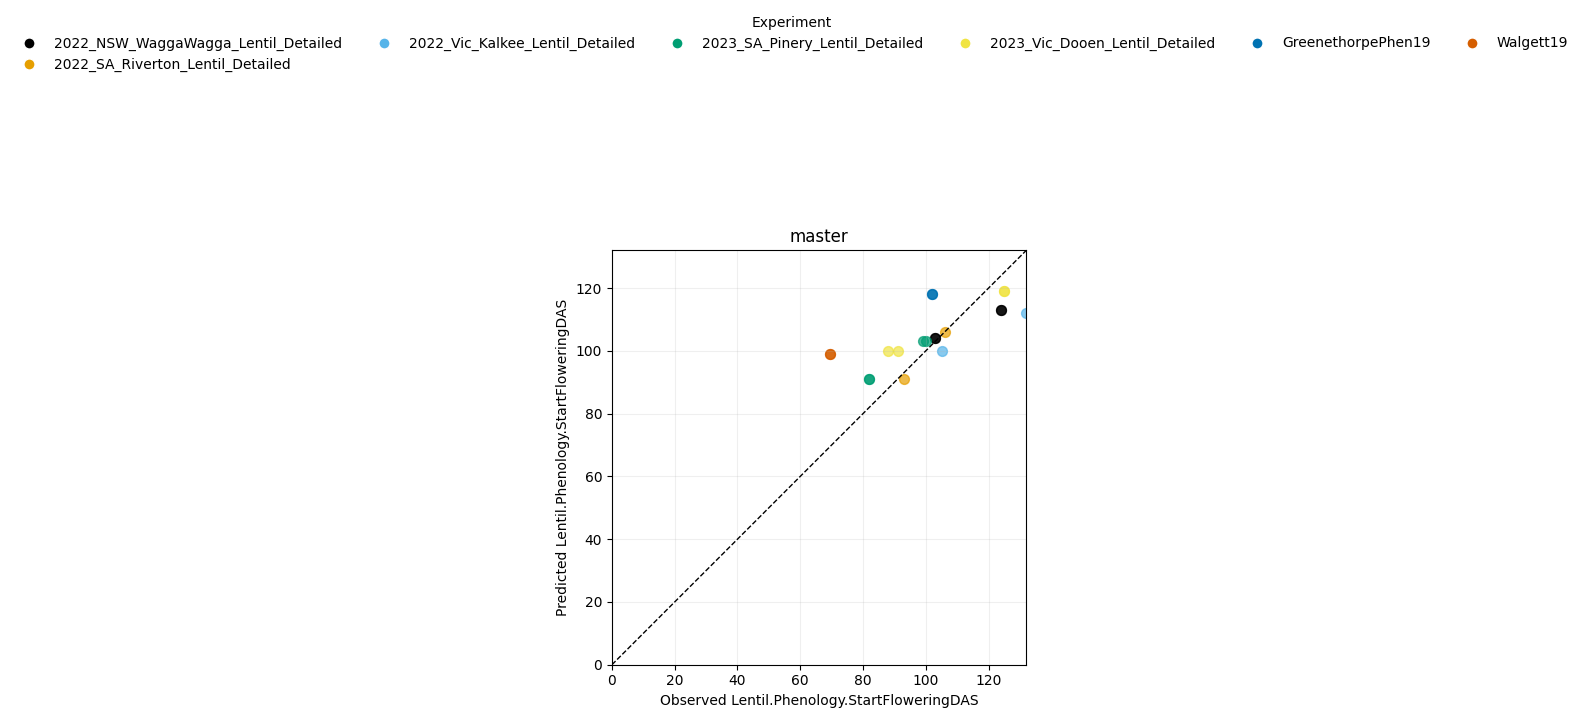

In [13]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.StartFloweringDAS",
    color_by = "Experiment",
    filters = {"Lentil.SowingData.Cultivar": ["Bolt"]}
)
plt.show()

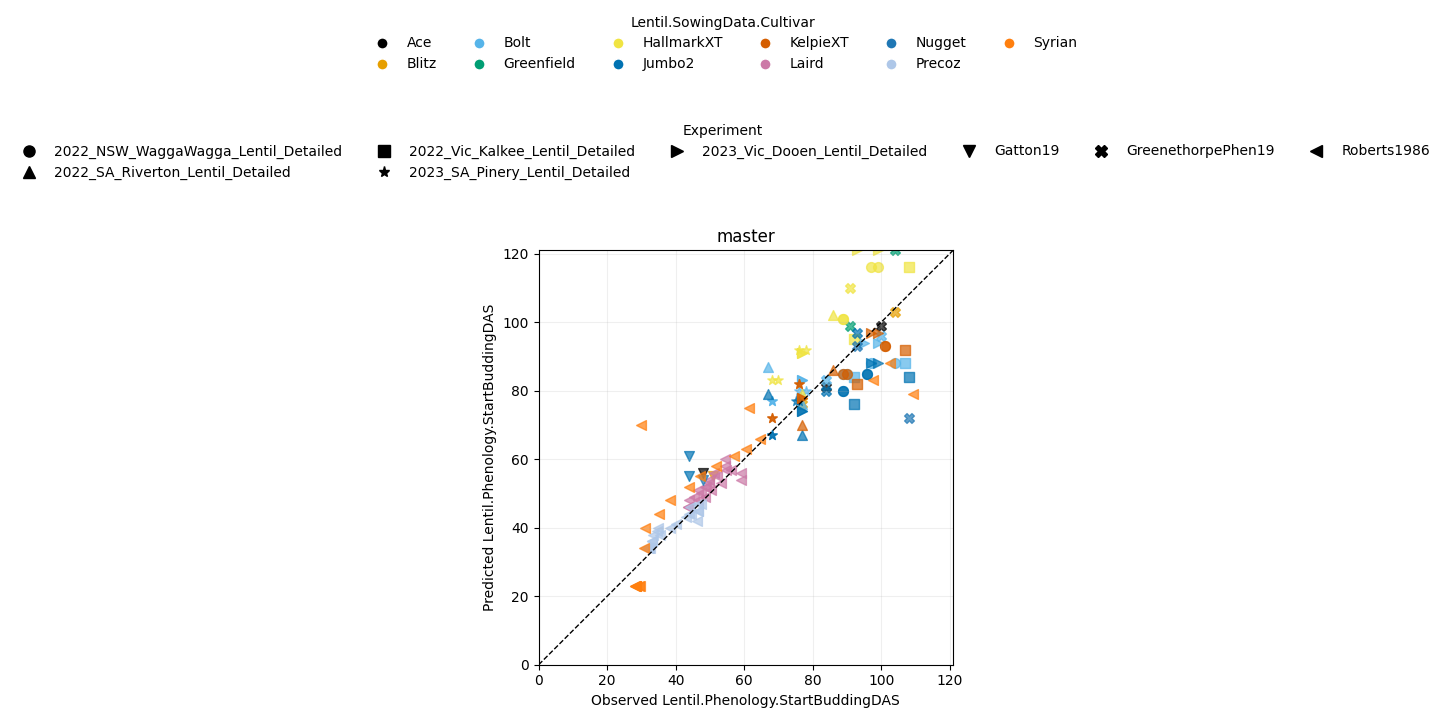

In [14]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.StartBuddingDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()

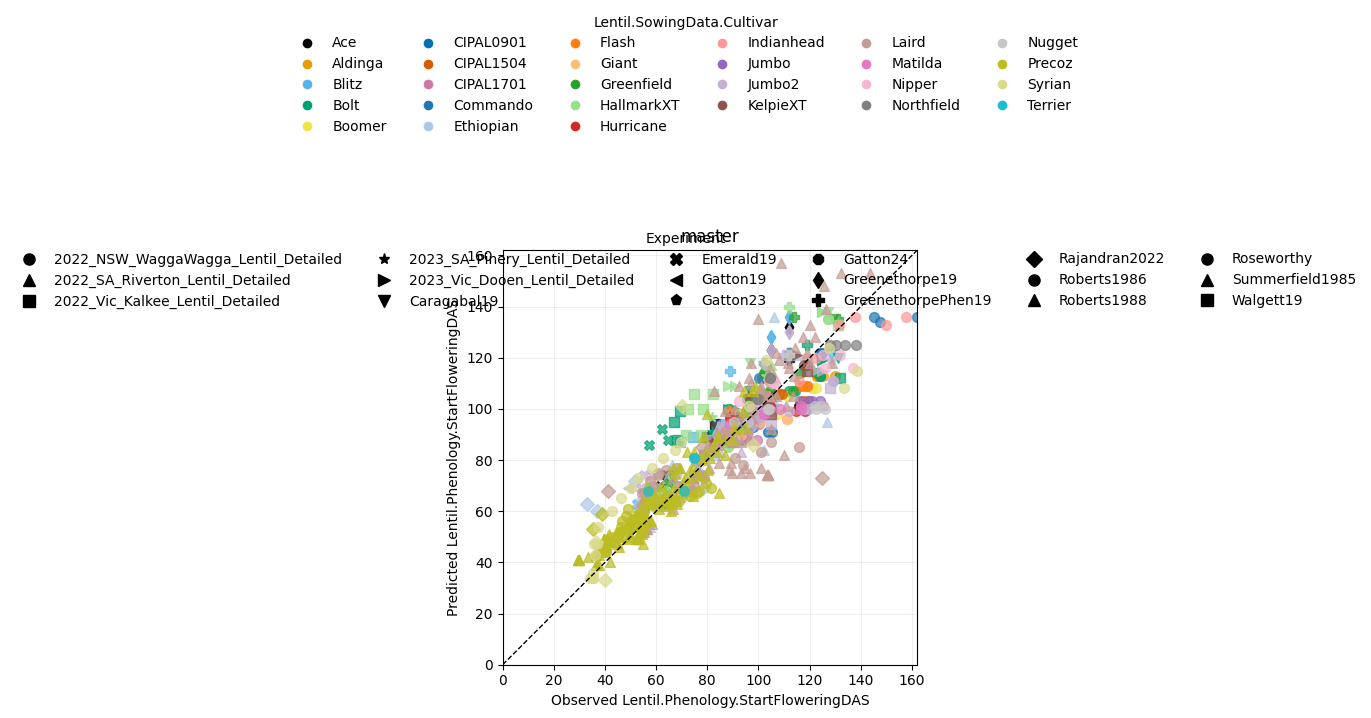

In [15]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.StartFloweringDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()

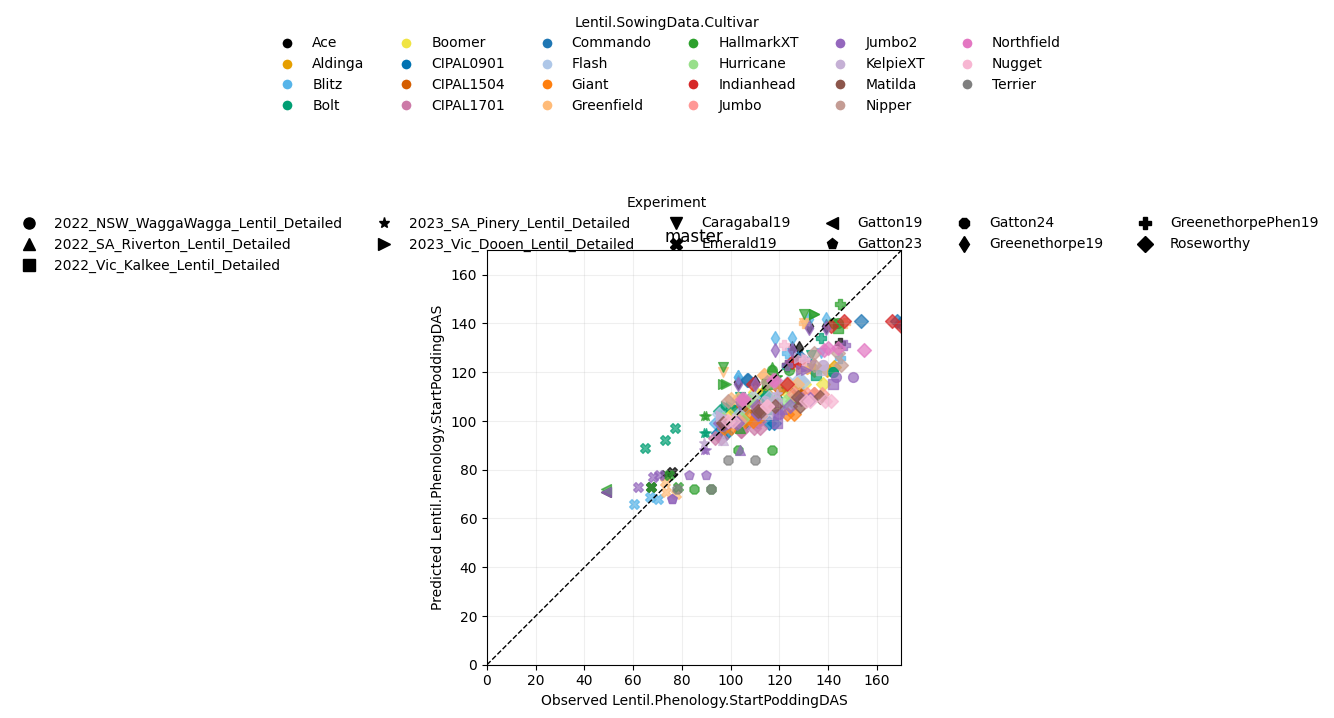

In [16]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.StartPoddingDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()

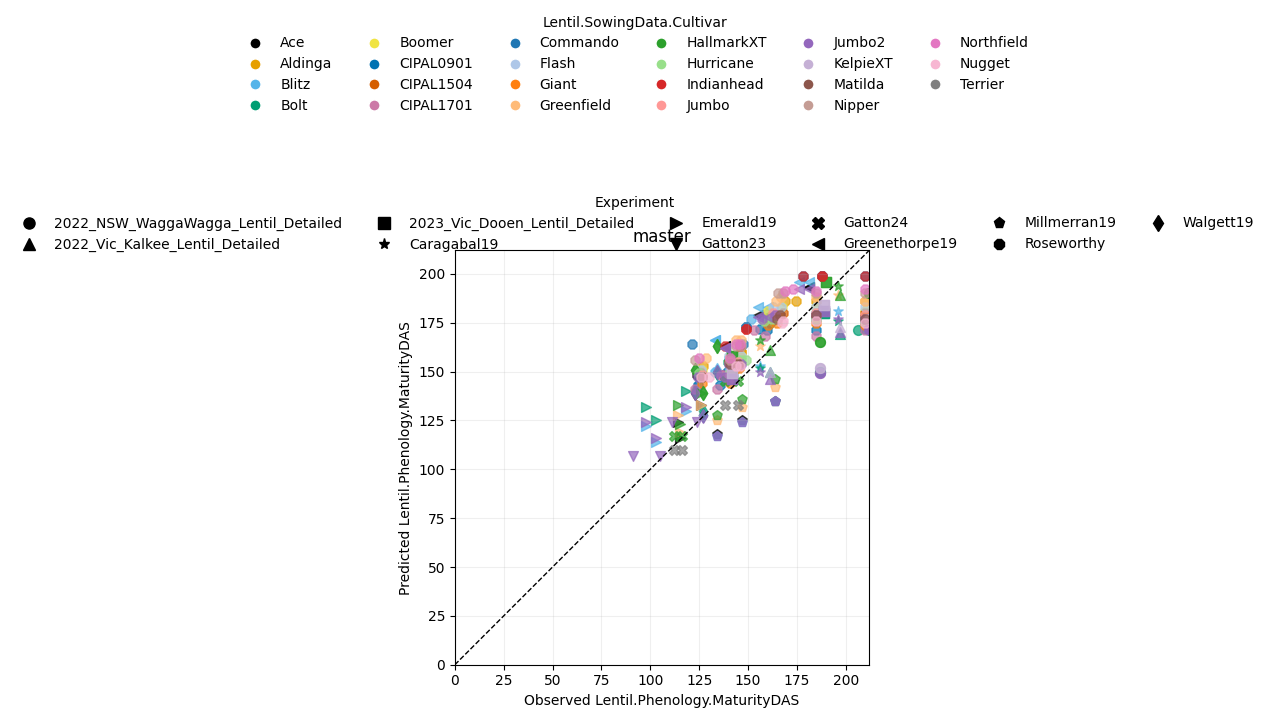

In [17]:
plot_obs_pred_by_branch(
    tidy,
    "Lentil.Phenology.MaturityDAS",
    color_by = "Lentil.SowingData.Cultivar",
    marker_by = "Experiment"
)
plt.show()

In [18]:
pivot = get_harvest_aligned(tidy, "Lentil.Phenology.StartPoddingDAS")

In [19]:
SumCols= ['Lentil.SowingData.Cultivar_pred','file','obs']
CvSum = pivot.loc[:,SumCols].groupby(by=['Lentil.SowingData.Cultivar_pred','file']).count()
CvSum

obs
Lentil.SowingData.Cultivar_pred file                                           
Ace                             Lentil.apsimx                                20
Aldinga                         Lentil.apsimx                                 8
Blitz                           Lentil.apsimx                                21
Bolt                            2022_NSW_WaggaWagga_Lentil_Detailed.apsimx    4
                                2022_SA_Riverton_Lentil_Detailed.apsimx       2
                                2022_Vic_Kalkee_Lentil_Detailed.apsimx        2
                                2023_SA_Pinery_Lentil_Detailed.apsimx         4
                                2023_Vic_Dooen_Lentil_Detailed.apsimx         4
                                Lentil.apsimx                                15
Boomer                          Lentil.apsimx                                 8
CIPAL0901                       Lentil.apsimx                                 8
CIPAL1504                       Lentil.apsimx                                 8
CIPAL1701                       Lentil.apsimx                                 8
Commando                        Lentil.apsimx                                 7
Flash                           Lentil.apsimx                                 8
Giant                           Lentil.apsimx                                 8
Greenfield                      Lentil.apsimx                                15
HallmarkXT                      2022_NSW_WaggaWagga_Lentil_Detailed.apsimx    4
                                2022_SA_Riverton_Lentil_Detailed.apsimx       2
                                2022_Vic_Kalkee_Lentil_Detailed.apsimx        2
                                2023_SA_Pinery_Lentil_Detailed.apsimx         4
                                2023_Vic_Dooen_Lentil_Detailed.apsimx         4
                                Lentil.apsimx                                11
Hurricane                       Lentil.apsimx                                 8
Indianhead                      Lentil.apsimx                                 8
Jumbo                           Lentil.apsimx                                 8
Jumbo2                          2022_NSW_WaggaWagga_Lentil_Detailed.apsimx    4
                                2022_SA_Riverton_Lentil_Detailed.apsimx       2
                                2022_Vic_Kalkee_Lentil_Detailed.apsimx        2
                                2023_SA_Pinery_Lentil_Detailed.apsimx         4
                                2023_Vic_Dooen_Lentil_Detailed.apsimx         4
                                Lentil.apsimx                                26
KelpieXT                        2022_NSW_WaggaWagga_Lentil_Detailed.apsimx    4
                                2022_SA_Riverton_Lentil_Detailed.apsimx       2
                                2022_Vic_Kalkee_Lentil_Detailed.apsimx        2
                                2023_SA_Pinery_Lentil_Detailed.apsimx         4
                                2023_Vic_Dooen_Lentil_Detailed.apsimx         4
Matilda                         Lentil.apsimx                                 7
Nipper                          Lentil.apsimx                                 8
Northfield                      Lentil.apsimx                                 8
Nugget                          Lentil.apsimx                                10
Terrier                         Lentil.apsimx                                 4

In [20]:
# Convert MultiIndex → DataFrame
idx_df = CvSum.index.to_frame(index=False)

# Group by cultivar → collect file list
cultivar_file_dict = (
    idx_df.groupby('Lentil.SowingData.Cultivar_pred')['file']
    .apply(list)
    .to_dict()
)

In [21]:
cultivar_file_dict

{'Ace': ['Lentil.apsimx'],
 'Aldinga': ['Lentil.apsimx'],
 'Blitz': ['Lentil.apsimx'],
 'Bolt': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'Lentil.apsimx'],
 'Boomer': ['Lentil.apsimx'],
 'CIPAL0901': ['Lentil.apsimx'],
 'CIPAL1504': ['Lentil.apsimx'],
 'CIPAL1701': ['Lentil.apsimx'],
 'Commando': ['Lentil.apsimx'],
 'Flash': ['Lentil.apsimx'],
 'Giant': ['Lentil.apsimx'],
 'Greenfield': ['Lentil.apsimx'],
 'HallmarkXT': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx',
  '2022_SA_Riverton_Lentil_Detailed.apsimx',
  '2022_Vic_Kalkee_Lentil_Detailed.apsimx',
  '2023_SA_Pinery_Lentil_Detailed.apsimx',
  '2023_Vic_Dooen_Lentil_Detailed.apsimx',
  'Lentil.apsimx'],
 'Hurricane': ['Lentil.apsimx'],
 'Indianhead': ['Lentil.apsimx'],
 'Jumbo': ['Lentil.apsimx'],
 'Jumbo2': ['2022_NSW_WaggaWagga_Lentil_Detailed.apsimx'

In [22]:
SumCols= ['Lentil.SowingData.Cultivar_pred','file','obs']
pivot.loc[:,SumCols].groupby(by=['Lentil.SowingData.Cultivar_pred']).count()

,file,obs
Lentil.SowingData.Cultivar_pred,,
Ace,20,20
Aldinga,8,8
Blitz,21,21
Bolt,31,31
Boomer,8,8
CIPAL0901,8,8
CIPAL1504,8,8
CIPAL1701,8,8
Commando,7,7
